In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

In [15]:
# Load saved embeddings and metadata
X = np.load("extracted-features/sentencetransformer_embeddings.npy")
meta = pd.read_csv("extracted-features/sentencetransformer_meta.csv")

sample_size = 500000
data_idx = meta.sample(sample_size, random_state=42).index
X_sample = X[data_idx]
y_sent = meta.loc[data_idx, 'sentiment'].values
y_star = meta.loc[data_idx, 'stars'].values - 1

# Train/test split
X_train, X_test, y_star_train, y_tar_test = train_test_split(
    X_sample, y_star, test_size=0.1, random_state=42, stratify=y_star
)

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_star_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_tar_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [17]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, num_classes=5):
        super(SimpleMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = SimpleMLP()

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
loss_vec = []

# Training loop
for epoch in range(100):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_loader):.4f}")
    loss_vec.append(total_loss/len(train_loader))


Epoch 1 - Loss: 0.9408
Epoch 2 - Loss: 0.9101
Epoch 3 - Loss: 0.9013
Epoch 4 - Loss: 0.8950
Epoch 5 - Loss: 0.8904
Epoch 6 - Loss: 0.8869
Epoch 7 - Loss: 0.8840
Epoch 8 - Loss: 0.8807
Epoch 9 - Loss: 0.8789
Epoch 10 - Loss: 0.8765
Epoch 11 - Loss: 0.8749
Epoch 12 - Loss: 0.8728
Epoch 13 - Loss: 0.8714
Epoch 14 - Loss: 0.8696
Epoch 15 - Loss: 0.8677
Epoch 16 - Loss: 0.8672
Epoch 17 - Loss: 0.8659
Epoch 18 - Loss: 0.8643
Epoch 19 - Loss: 0.8634
Epoch 20 - Loss: 0.8624
Epoch 21 - Loss: 0.8616
Epoch 22 - Loss: 0.8609
Epoch 23 - Loss: 0.8600
Epoch 24 - Loss: 0.8592
Epoch 25 - Loss: 0.8588
Epoch 26 - Loss: 0.8579
Epoch 27 - Loss: 0.8571
Epoch 28 - Loss: 0.8558
Epoch 29 - Loss: 0.8547
Epoch 30 - Loss: 0.8548
Epoch 31 - Loss: 0.8543
Epoch 32 - Loss: 0.8539
Epoch 33 - Loss: 0.8532
Epoch 34 - Loss: 0.8526
Epoch 35 - Loss: 0.8520
Epoch 36 - Loss: 0.8520
Epoch 37 - Loss: 0.8516
Epoch 38 - Loss: 0.8504
Epoch 39 - Loss: 0.8500
Epoch 40 - Loss: 0.8498
Epoch 41 - Loss: 0.8489
Epoch 42 - Loss: 0.8488
E

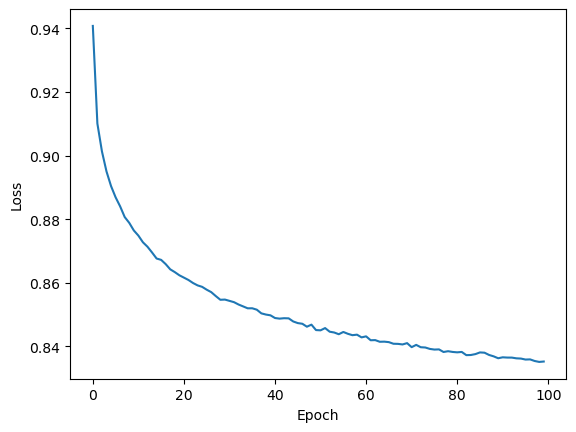

In [19]:
fig = plt.figure()
plt.plot(loss_vec)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [20]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print(f"Test Accuracy: {correct/total:.4f}")

Test Accuracy: 0.6213
